In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os
import joblib
from math import pi
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [3]:
# Dataset configurations (you just need to keep adding your dataset to this directory and add the target variable name + the dataset name)
DATASETS = {
    "calingiri": {
        "file": "3_merged_data3.txt",
        "target": "avg7_calingiri",
        "display_name": "Calingiri"
    },
    "lancer": {
        "file": "3_merged_data1.txt", 
        "target": "avg7_lancer",
        "display_name": "Lancer"
    },
    "halberd": {
        "file": "3_merged_data5.txt",
        "target": "avg_halberd",
        "display_name": "Halberd"
    }
}

In [4]:
# Models
def get_models():
    return {
        'DecisionTree': DecisionTreeRegressor(),
        #'RandomForest': RandomForestRegressor(n_jobs=2),
        'GradientBoosting': GradientBoostingRegressor(),
        'LinearRegression': LinearRegression(),
        #'LassoRegression': Lasso(),
    }


In [5]:
# Parameters (preserved from original)
k_values = [3, 5]  # I used 2 for simplicity. If more accuracy is to be tested, this can be increased
population_size = 20
mutation_rate = 0.1
num_generations = 10

# Global variables for current dataset (will be set during processing)
X_train = None
y_train = None
X_test = None
y_test = None

# Genetic Algorithm functions (preserved from original)
def initialize_population():
    np.random.seed(42)
    population = []
    for _ in range(population_size):
        features = np.random.randint(2, size=X_train.shape[1])
        population.append(features)
    return population

def decode_individual(individual):
    return individual.astype(int)

def fitness_function(individual, model, kfold):
    features = decode_individual(individual)
    selected_cols = [i for i, bit in enumerate(features) if bit == 1]
    if len(selected_cols) == 0:
        return np.inf
    X_selected = X_train.iloc[:, selected_cols]
    scores = -1 * cross_val_score(model, X_selected, y_train, cv=kfold,
                                 scoring='neg_mean_squared_error', n_jobs=-1)
    return scores.mean()

def selection(population, scores):
    selected = []
    for _ in range(len(population)):
        i1, i2 = random.sample(range(len(population)), 2)
        selected.append(population[i1] if scores[i1] < scores[i2] else population[i2])
    return selected

def crossover(p1, p2):
    split_point = random.randint(1, len(p1) - 1)
    child1 = np.concatenate((p1[:split_point], p2[split_point:]))
    child2 = np.concatenate((p2[:split_point], p1[split_point:]))
    return child1, child2

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = 1 - individual[i]
    return individual


In [6]:

# Training function (preserved from original with dataset support)
def train_genetic_algorithm(models, dataset_name, save_dir):
    """Train genetic algorithm for feature selection on a specific dataset"""
    
    results = []
    
    print(f"\n🧬 Starting Genetic Algorithm training for {dataset_name}")
    print(f"Population size: {population_size}, Generations: {num_generations}")
    print(f"Models to test: {list(models.keys())}")
    
    for model_name, model in models.items():
        for k in k_values:
            print(f"\\nRunning GA for {model_name} with k={k} folds CV - {dataset_name}")
            kfold = KFold(n_splits=k, shuffle=True, random_state=42)
            population = initialize_population()

            gen_mse_progress = []

            for gen in tqdm(range(num_generations), desc=f"GA {model_name} k={k} - {dataset_name}"):
                scores = [fitness_function(ind, model, kfold) for ind in population]
                gen_mse_progress.append(np.min(scores))
                sorted_pop = [x for _, x in sorted(zip(scores, population), key=lambda pair: pair[0])]
                population = sorted_pop[:population_size//2]

                next_gen = population.copy()
                while len(next_gen) < population_size:
                    p1, p2 = random.sample(population, 2)
                    c1, c2 = crossover(p1, p2)
                    next_gen.append(mutate(c1))
                    if len(next_gen) < population_size:
                        next_gen.append(mutate(c2))
                population = next_gen

            best_individual = sorted(population, key=lambda ind: fitness_function(ind, model, kfold))[0]
            best_features = decode_individual(best_individual)
            selected_cols = [i for i, bit in enumerate(best_features) if bit == 1]

            if len(selected_cols) == 0:
                print("Warning: No features selected, skipping this configuration.")
                continue

            model.fit(X_train.iloc[:, selected_cols], y_train)
            y_pred = model.predict(X_test.iloc[:, selected_cols])

            mse = mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            cv_mse = fitness_function(best_individual, model, kfold)

            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'K_Folds': k,
                'CV_MSE': cv_mse,
                'Test_MSE': mse,
                'Test_MAE': mae,
                'Test_R2': r2,
                'Num_Features': len(selected_cols),
                'MSE_Progress': gen_mse_progress
            })

            # Save model with meaningful name including dataset
            model_filename = f"{dataset_name}_{model_name}_k{k}_best_model.joblib"
            model_path = os.path.join(save_dir, model_filename)
            joblib.dump({
                'model': model,
                'selected_features': selected_cols
            }, model_path)

            print(f"Saved best model for {model_name} with k={k} at {model_path}")

    return results


In [7]:

# Best model evaluation (preserved from original with dataset support)
def evaluate_best_model(summary_df, dataset_name, save_dir):
    """Evaluate the best model for a specific dataset"""
    
    # Choose metric to pick best model
    # For MSE lower is better, for R2 higher is better
    metric = 'Test_MSE'  # or 'Test_R2'

    # Find the best row based on metric
    if metric == 'Test_MSE':
        best_idx = summary_df[metric].idxmin()
    elif metric == 'Test_R2':
        best_idx = summary_df[metric].idxmax()
    else:
        raise ValueError("Unsupported metric for selection")

    best_model_info = summary_df.loc[best_idx]
    model_name = best_model_info['Model']
    k = best_model_info['K_Folds']

    print(f"\\n🏆 Best model for {dataset_name} by {metric}: {model_name} with k={k}")

    # Build the path to the saved model file
    model_filename = f"{dataset_name}_{model_name}_k{k}_best_model.joblib"
    model_path = os.path.join(save_dir, model_filename)

    # Load model and selected features
    loaded_data = joblib.load(model_path)
    loaded_model = loaded_data['model']
    selected_features = loaded_data['selected_features']

    print(f"Loaded model: {loaded_model}")
    print(f"Selected features count: {len(selected_features)}")

    # Run inference on test set with selected features
    X_test_selected = X_test.iloc[:, selected_features]
    y_pred = loaded_model.predict(X_test_selected)

    # Calculate performance metrics on test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\\nPerformance on Test Set for {dataset_name}:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R2): {r2:.4f}")

    # Show 10 predictions and their corresponding true values side-by-side
    comparison_df = pd.DataFrame({
        'Predicted': y_pred[:10],
        'Actual': y_test.iloc[:10].values
    })

    print(f"\\nSample Predictions vs Actual Values for {dataset_name}:")
    print(comparison_df)
    
    return best_model_info, y_pred, loaded_model, selected_features


In [8]:

# Visualization functions (preserved from original with dataset support)
def plot_mse_progression(results, dataset_name):
    """MSE Line Plot over Generations"""
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 6))
    for row in results:
        label = f"{row['Model']} (k={row['K_Folds']})"
        plt.plot(row['MSE_Progress'], label=label)
    plt.title(f"Best MSE Progression Over Generations (GA) - {dataset_name}")
    plt.xlabel("Generation")
    plt.ylabel("Best MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [9]:
def plot_model_performance_kfold(summary_df, dataset_name):
    """Model Performance (Test MSE) Across K-Fold Values"""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=summary_df, x='K_Folds', y='Test_MSE', hue='Model', marker='o')
    plt.title(f'Model Performance (Test MSE) Across K-Fold Values - {dataset_name}')
    plt.ylabel('Test MSE')
    plt.xticks(summary_df['K_Folds'].unique())
    plt.tight_layout()
    plt.show()


In [10]:
def plot_radar_for_model(df, model_name, dataset_name):
    """Radar Plot (Spider Chart) per Model"""
    df_model = df[df['Model'] == model_name].mean(numeric_only=True)
    metrics = ['Test_MSE', 'Test_MAE', 'Test_R2', 'CV_MSE']
    values = df_model[metrics].values.tolist()
    values += values[:1]  # loop back to start
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], metrics)
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name)
    ax.fill(angles, values, alpha=0.25)
    plt.title(f'Radar Chart - {model_name} - {dataset_name}', y=1.08)
    plt.legend()
    plt.show()


In [11]:

def plot_boxplots_metrics(summary_df, dataset_name):
    """Boxplots for all metrics"""
    metrics = ['Test_MSE', 'Test_MAE', 'Test_R2']
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=summary_df, x='Model', y=metric, hue='K_Folds')
        plt.title(f'Distribution of {metric} across Models and K-Folds - {dataset_name}')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

In [12]:
def plot_efficiency_vs_accuracy(summary_df, dataset_name):
    """Efficiency (Num Features) vs Accuracy (Test R²)"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=summary_df, x='Num_Features', y='Test_R2', hue='Model', style='K_Folds', s=120)
    plt.title(f"Efficiency (Num Features) vs Accuracy (Test R²) - {dataset_name}")
    plt.xlabel("Number of Selected Features")
    plt.ylabel("Test R² Score")
    plt.legend(title='Model / K')
    plt.tight_layout()
    plt.show()

In [13]:
def plot_test_mse_barplot(summary_df, dataset_name):
    """Test MSE by Model and K-Folds"""
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=summary_df, x='Model', y='Test_MSE', hue='K_Folds')
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)
    plt.title(f'Test MSE by Model and Number of Folds - {dataset_name}')
    plt.ylabel('Test MSE')
    plt.xlabel('Model')
    plt.legend(title='K-Folds')
    plt.tight_layout()
    plt.show()


In [14]:

def plot_heatmap_mse(summary_df, dataset_name):
    """Heatmap of Test MSE"""
    pivot_mse = summary_df.pivot(index="Model", columns="K_Folds", values="Test_MSE")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_mse, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Test MSE'})
    plt.title(f"Heatmap of Test MSE by Model and K-Folds - {dataset_name}")
    plt.ylabel("Model")
    plt.xlabel("K-Folds")
    plt.tight_layout()
    plt.show()

In [15]:
def plot_scatter_r2_vs_mse(summary_df, dataset_name):
    """Scatter Plot (R² vs Test MSE) with All Models and K-Folds"""
    plt.figure(figsize=(10, 7))
    sns.set(style='whitegrid')

    # Add hue for model, style for k-folds, and size for number of selected features
    scatter = sns.scatterplot(
        data=summary_df,
        x='Test_MSE',
        y='Test_R2',
        hue='Model',
        style='K_Folds',
        size='Num_Features',
        sizes=(50, 200),
        palette='tab10'
    )

    # Add text labels for clarity
    for idx, row in summary_df.iterrows():
        plt.text(
            row['Test_MSE'] + 0.001,
            row['Test_R2'],
            f"{row['Model']}_k{row['K_Folds']}",
            fontsize=9,
            alpha=0.7
        )

    plt.title(f'Model Comparison: R² vs Test MSE (All Models and K-Folds) - {dataset_name}')
    plt.xlabel('Test MSE (Lower is Better)')
    plt.ylabel('R² Score (Higher is Better)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model / Fold / Feature Size')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [16]:
def create_all_visualizations(results, summary_df, dataset_name):
    """Create all visualizations for a dataset"""
    print(f"\\n📈 Creating visualizations for {dataset_name}...")
    
    # 1. MSE progression over generations
    plot_mse_progression(results, dataset_name)
    
    # 2. Model performance across K-fold values
    plot_model_performance_kfold(summary_df, dataset_name)
    
    # 3. Radar plots for each model
    for model in summary_df['Model'].unique():
        plot_radar_for_model(summary_df, model, dataset_name)
    
    # 4. Boxplots for all metrics
    plot_boxplots_metrics(summary_df, dataset_name)
    
    # 5. Efficiency vs accuracy
    plot_efficiency_vs_accuracy(summary_df, dataset_name)
    
    # 6. Test MSE bar plot
    plot_test_mse_barplot(summary_df, dataset_name)
    
    # 7. Heatmap of Test MSE
    plot_heatmap_mse(summary_df, dataset_name)
    
    # 8. Scatter plot R² vs MSE
    plot_scatter_r2_vs_mse(summary_df, dataset_name)


In [17]:

# Cross-dataset summary functions
def create_cross_dataset_summary(all_results):
    """Create a summary comparison across all datasets"""
    summary_data = []
    
    for dataset_name, summary_df in all_results.items():
        # Get best model for each dataset
        best_idx = summary_df['Test_MSE'].idxmin()
        best_model = summary_df.loc[best_idx]
        
        summary_data.append({
            'Dataset': dataset_name,
            'Best_Model': best_model['Model'],
            'K_Folds': best_model['K_Folds'],
            'Test_MSE': best_model['Test_MSE'],
            'Test_MAE': best_model['Test_MAE'],
            'Test_R2': best_model['Test_R2'],
            'CV_MSE': best_model['CV_MSE'],
            'Num_Features': best_model['Num_Features']
        })
    
    cross_summary_df = pd.DataFrame(summary_data)
    
    # Plot cross-dataset comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Test MSE comparison
    sns.barplot(data=cross_summary_df, x='Dataset', y='Test_MSE', ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Best Test MSE by Dataset')
    axes[0,0].set_ylabel('Test MSE')
    
    # Test R² comparison
    sns.barplot(data=cross_summary_df, x='Dataset', y='Test_R2', ax=axes[0,1], palette='plasma')
    axes[0,1].set_title('Best Test R² by Dataset')
    axes[0,1].set_ylabel('Test R²')
    
    # Test MAE comparison
    sns.barplot(data=cross_summary_df, x='Dataset', y='Test_MAE', ax=axes[0,2], palette='cividis')
    axes[0,2].set_title('Best Test MAE by Dataset')
    axes[0,2].set_ylabel('Test MAE')
    
    # Number of features comparison
    sns.barplot(data=cross_summary_df, x='Dataset', y='Num_Features', ax=axes[1,0], palette='magma')
    axes[1,0].set_title('Number of Selected Features by Dataset')
    axes[1,0].set_ylabel('Number of Features')
    
    # CV MSE comparison
    sns.barplot(data=cross_summary_df, x='Dataset', y='CV_MSE', ax=axes[1,1], palette='coolwarm')
    axes[1,1].set_title('Best CV MSE by Dataset')
    axes[1,1].set_ylabel('CV MSE')
    
    # Best model comparison
    model_counts = cross_summary_df['Best_Model'].value_counts()
    axes[1,2].pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%')
    axes[1,2].set_title('Distribution of Best Models Across Datasets')
    
    plt.suptitle('Genetic Algorithm Performance Summary Across All Datasets', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return cross_summary_df


In [18]:

# Main execution function
def main():
    """Main execution function that processes all datasets"""
    global X_train, y_train, X_test, y_test
    
    print("🧬 Multi-Dataset Genetic Algorithm Feature Selection Pipeline")
    print("="*70)
    
    # Storage for all results
    all_results = {}
    all_best_models = {}
    
    # Process each dataset
    for dataset_key, dataset_config in DATASETS.items():
        print(f"\\n{'='*70}")
        print(f"Processing Dataset: {dataset_config['display_name']}")
        print(f"File: {dataset_config['file']}")
        print(f"Target: {dataset_config['target']}")
        print(f"{'='*70}")
        
        try:
            # Load data (preserved from original)
            df = pd.read_csv(dataset_config['file'], sep='\\t')
            print(f"Dataset shape: {df.shape}")

            # Prepare data (preserved from original)
            X = df.drop(columns=['ID', dataset_config['target']])
            y = df[dataset_config['target']]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            print(f'Shape of X_train: {X_train.shape}')
            print(f'Shape of X_test: {X_test.shape}')

            # Create directory for models
            save_dir = f"saved_models_genetic_{dataset_key}"
            os.makedirs(save_dir, exist_ok=True)

            # Get models (preserved from original)
            models = get_models()

            # Train genetic algorithm (preserved methodology)
            results = train_genetic_algorithm(models, dataset_config['display_name'], save_dir)

            # Create summary dataframe
            summary_df = pd.DataFrame(results)
            print(f"\\nSummary for {dataset_config['display_name']}:\\n", summary_df)

            # Save the summary results to a CSV file
            summary_csv_path = f'{dataset_key}_model_comparison_summary.csv'
            summary_df.to_csv(summary_csv_path, index=False)
            print(f"\\nSummary saved to: {summary_csv_path}")
            
            # Store results
            all_results[dataset_config['display_name']] = summary_df

            # Evaluate best model (preserved from original)
            best_model_info, y_pred, loaded_model, selected_features = evaluate_best_model(
                summary_df, dataset_config['display_name'], save_dir
            )
            
            # Store best model info
            all_best_models[dataset_config['display_name']] = {
                'best_model_info': best_model_info,
                'y_pred': y_pred,
                'loaded_model': loaded_model,
                'selected_features': selected_features,
                'y_test': y_test
            }

            # Create all visualizations (preserved from original)
            create_all_visualizations(results, summary_df, dataset_config['display_name'])
            
            print(f"✅ Completed processing for {dataset_config['display_name']}")
            
        except Exception as e:
            print(f"❌ Error processing {dataset_key}: {str(e)}")
            continue
    
    # Create cross-dataset summary
    if all_results:
        print(f"\\n{'='*70}")
        print("Creating Cross-Dataset Summary Comparison")
        print(f"{'='*70}")
        
        cross_summary_df = create_cross_dataset_summary(all_results)
        cross_summary_df.to_csv("genetic_algorithm_cross_dataset_summary.csv", index=False)
        
        print("\\n📊 Cross-Dataset Final Summary:")
        print(cross_summary_df.to_string(index=False))
        
        # Print detailed best model results
        print(f"\\n{'='*70}")
        print("Best Model Performance Summary by Dataset")
        print(f"{'='*70}")
        
        for dataset_name, best_info in all_best_models.items():
            print(f"\\n{dataset_name}:")
            print(f"  Best Model: {best_info['best_model_info']['Model']}")
            print(f"  K-Folds: {best_info['best_model_info']['K_Folds']}")
            print(f"  Selected Features: {len(best_info['selected_features'])}")
            print(f"  Test MSE: {best_info['best_model_info']['Test_MSE']:.4f}")
            print(f"  Test MAE: {best_info['best_model_info']['Test_MAE']:.4f}")
            print(f"  Test R²: {best_info['best_model_info']['Test_R2']:.4f}")
    
    print(f"\\n{'='*70}")
    print("🎉 Multi-Dataset Genetic Algorithm Analysis Complete!")
    print(f"{'='*70}")

🧬 Multi-Dataset Genetic Algorithm Feature Selection Pipeline
\n======================================================================
Processing Dataset: Calingiri
File: 3_merged_data3.txt
Target: avg7_calingiri
Dataset shape: (149, 33050)
Shape of X_train: (119, 33048)
Shape of X_test: (30, 33048)

🧬 Starting Genetic Algorithm training for Calingiri
Population size: 20, Generations: 10
Models to test: ['DecisionTree', 'GradientBoosting', 'LinearRegression']
\nRunning GA for DecisionTree with k=3 folds CV - Calingiri


GA DecisionTree k=3 - Calingiri: 100%|██████████| 10/10 [01:13<00:00,  7.35s/it]


Saved best model for DecisionTree with k=3 at saved_models_genetic_calingiri\Calingiri_DecisionTree_k3_best_model.joblib
\nRunning GA for DecisionTree with k=5 folds CV - Calingiri


GA DecisionTree k=5 - Calingiri: 100%|██████████| 10/10 [01:17<00:00,  7.76s/it]


Saved best model for DecisionTree with k=5 at saved_models_genetic_calingiri\Calingiri_DecisionTree_k5_best_model.joblib
\nRunning GA for GradientBoosting with k=3 folds CV - Calingiri


...

Saved best model for GradientBoosting with k=5 at saved_models_genetic_calingiri\Calingiri_GradientBoosting_k5_best_model.joblib
\nRunning GA for LinearRegression with k=3 folds CV - Calingiri


GA LinearRegression k=3 - Calingiri: 100%|██████████| 10/10 [01:03<00:00,  6.35s/it]


Saved best model for LinearRegression with k=3 at saved_models_genetic_calingiri\Calingiri_LinearRegression_k3_best_model.joblib
\nRunning GA for LinearRegression with k=5 folds CV - Calingiri


GA LinearRegression k=5 - Calingiri: 100%|██████████| 10/10 [01:30<00:00,  9.01s/it]


Saved best model for LinearRegression with k=5 at saved_models_genetic_calingiri\Calingiri_LinearRegression_k5_best_model.joblib
\nSummary for Calingiri:\n      Dataset             Model  K_Folds    CV_MSE  Test_MSE  Test_MAE  \
0  Calingiri      DecisionTree        3  2.297989  2.750240  1.422667   
1  Calingiri      DecisionTree        5  2.520320  3.440280  1.452000   
2  Calingiri  GradientBoosting        3  1.546957  1.437790  0.975389   
3  Calingiri  GradientBoosting        5  1.544252  1.168626  0.844637   
4  Calingiri  LinearRegression        3  1.683476  2.141895  1.196348   
5  Calingiri  LinearRegression        5  1.921779  1.982384  1.165763   

    Test_R2  Num_Features                                       MSE_Progress  
0 -0.996167         16439  [2.8288230982905986, 2.4115961324786324, 2.451...  
1 -1.497009         16486  [2.931957463768116, 3.004766376811594, 2.96459...  
2 -0.043570         16473  [1.6781293816440126, 1.649090281243122, 1.6552...  
3  0.151793     

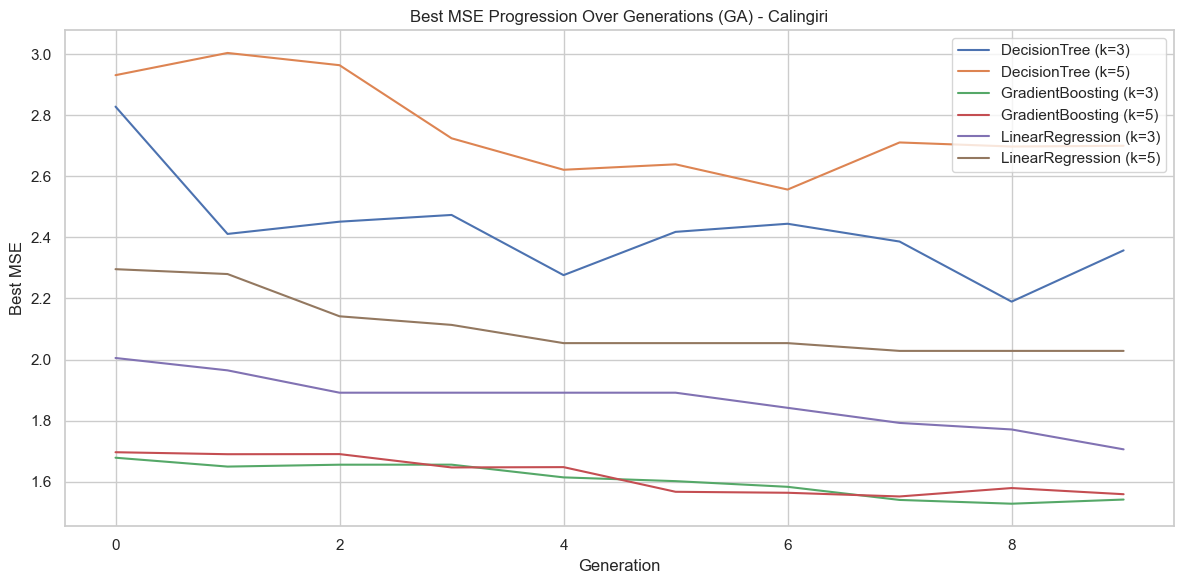

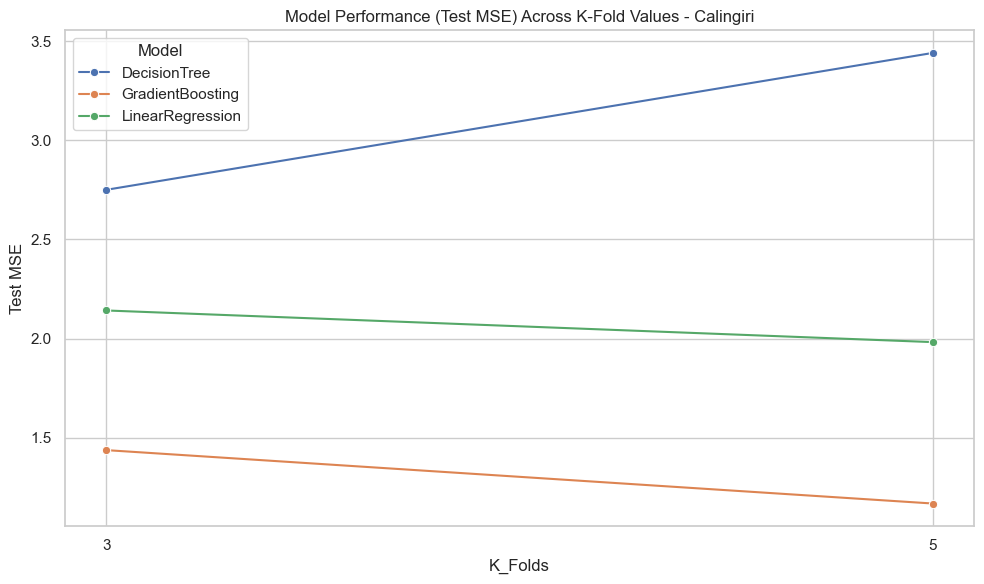

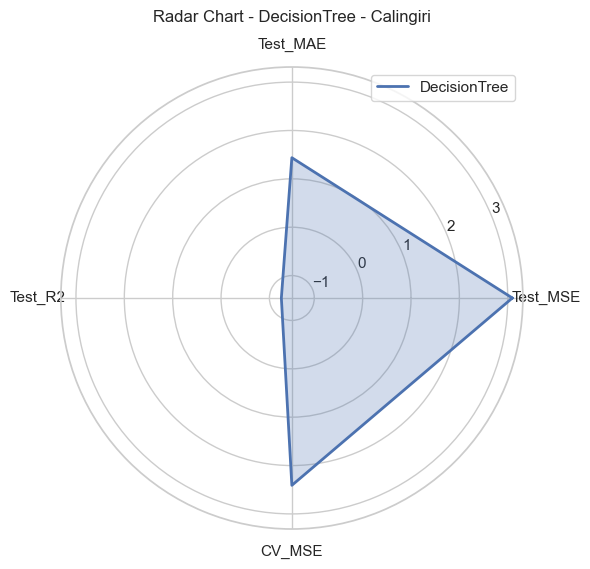

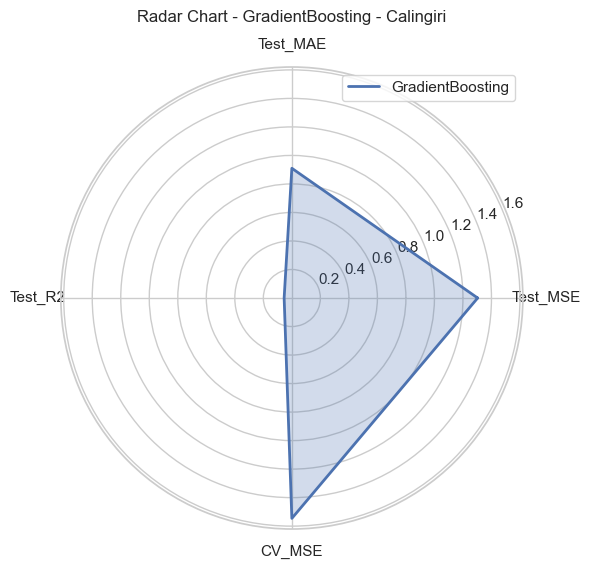

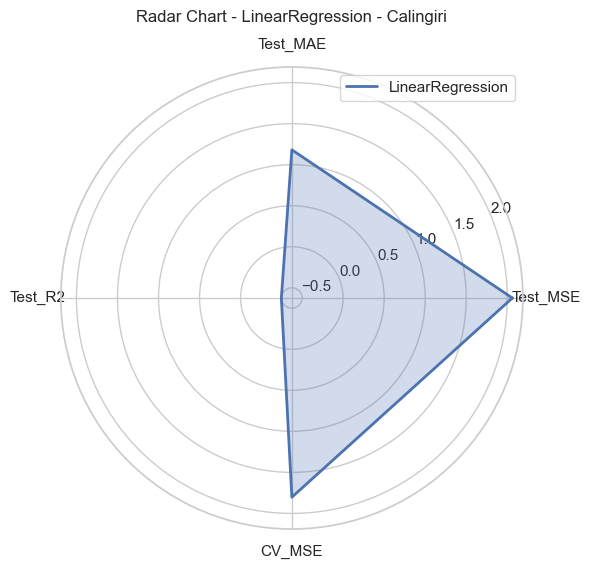

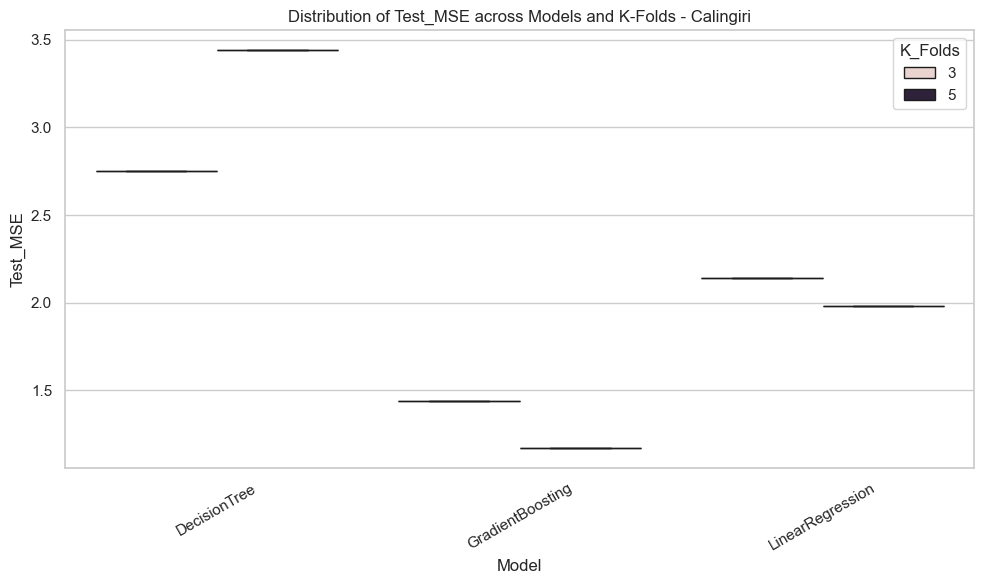

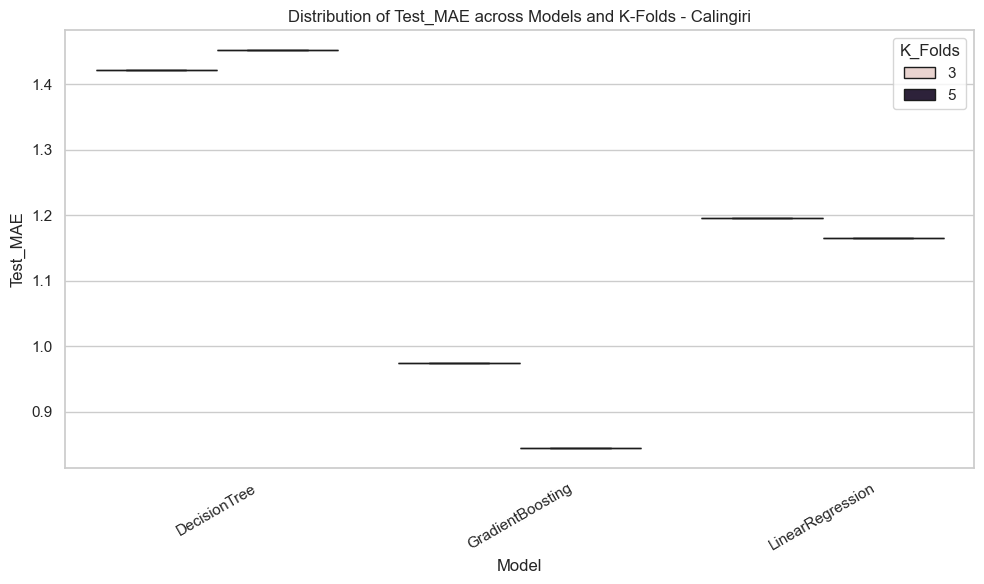

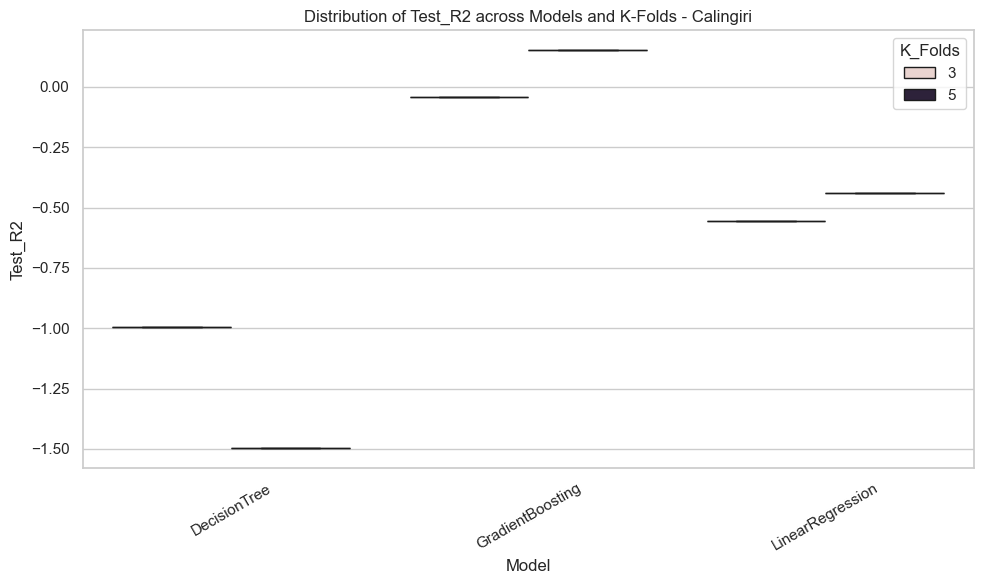

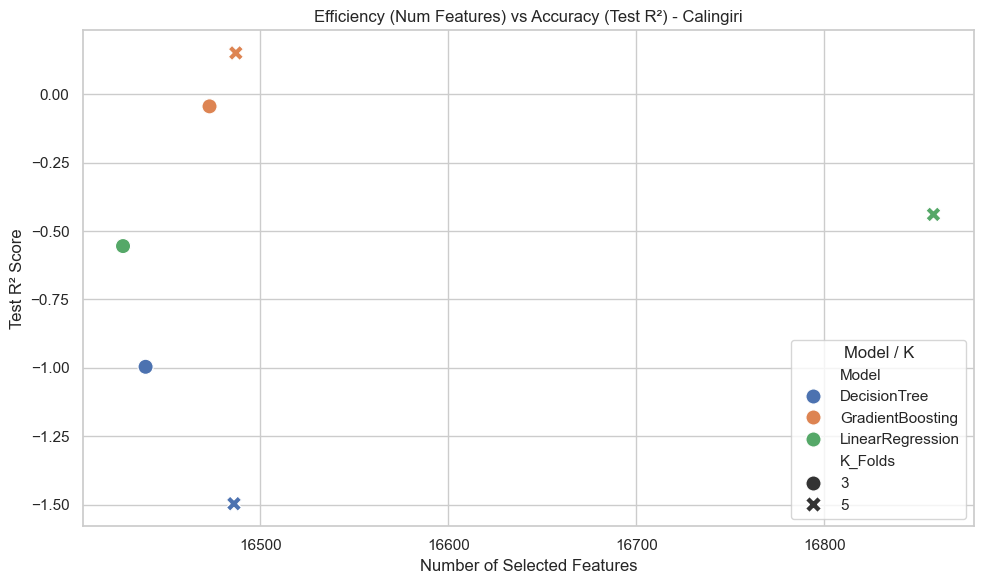

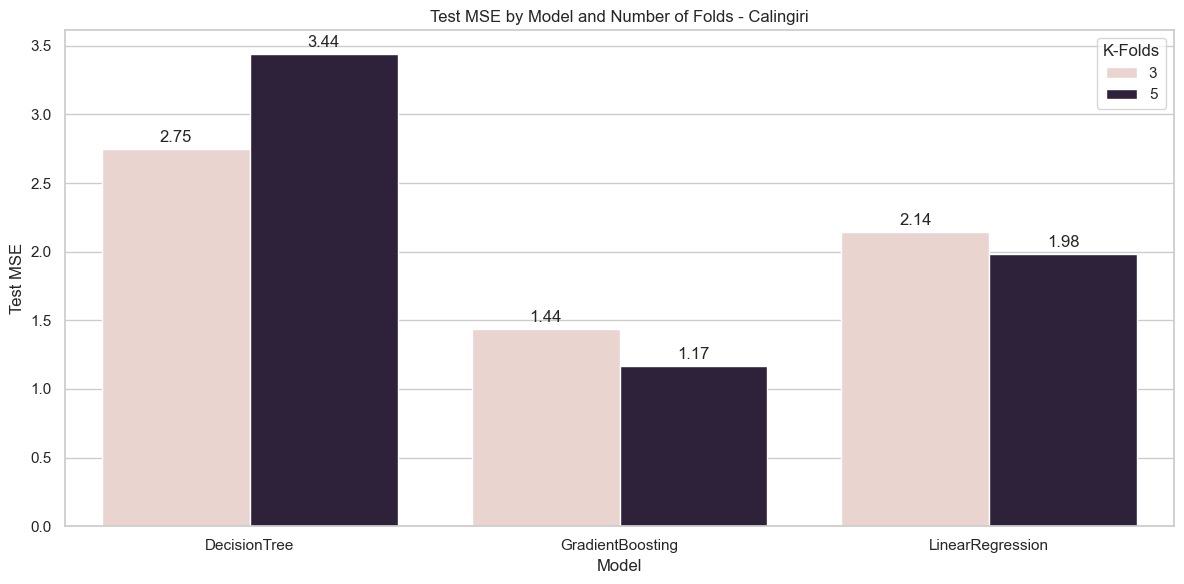

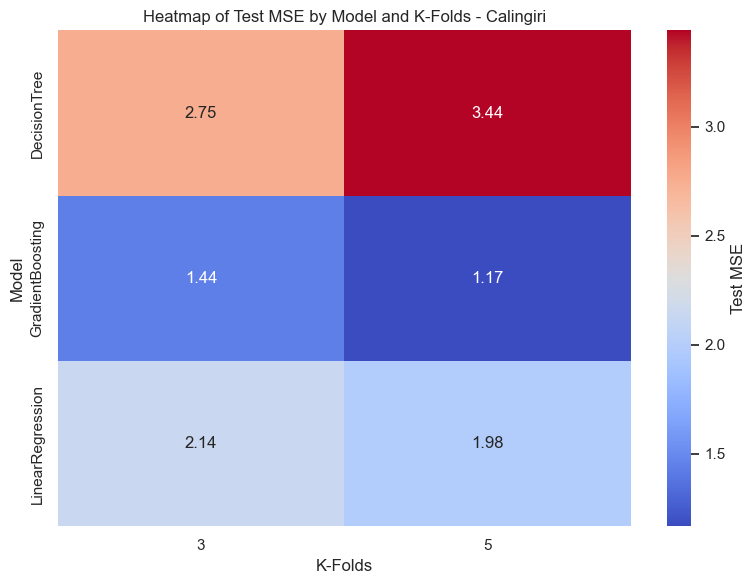

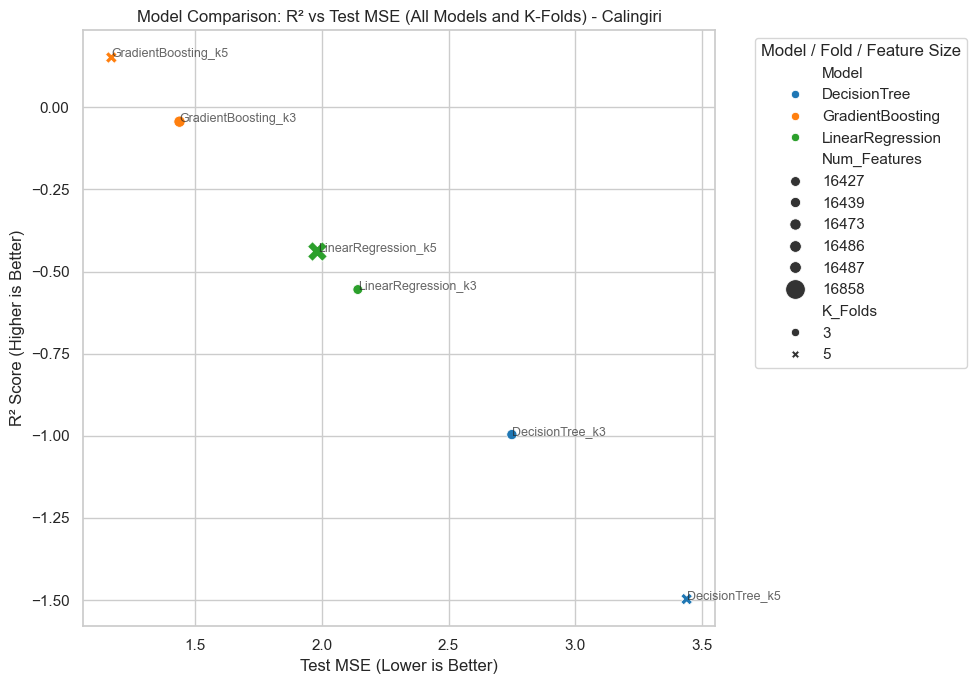

✅ Completed processing for Calingiri
\n======================================================================
Processing Dataset: Lancer
File: 3_merged_data1.txt
Target: avg7_lancer
Dataset shape: (149, 33050)
Shape of X_train: (119, 33048)
Shape of X_test: (30, 33048)

🧬 Starting Genetic Algorithm training for Lancer
Population size: 20, Generations: 10
Models to test: ['DecisionTree', 'GradientBoosting', 'LinearRegression']
\nRunning GA for DecisionTree with k=3 folds CV - Lancer


GA DecisionTree k=3 - Lancer: 100%|██████████| 10/10 [01:06<00:00,  6.67s/it]


Saved best model for DecisionTree with k=3 at saved_models_genetic_lancer\Lancer_DecisionTree_k3_best_model.joblib
\nRunning GA for DecisionTree with k=5 folds CV - Lancer


GA DecisionTree k=5 - Lancer: 100%|██████████| 10/10 [01:19<00:00,  7.99s/it]


Saved best model for DecisionTree with k=5 at saved_models_genetic_lancer\Lancer_DecisionTree_k5_best_model.joblib
\nRunning GA for GradientBoosting with k=3 folds CV - Lancer


...

Saved best model for GradientBoosting with k=5 at saved_models_genetic_lancer\Lancer_GradientBoosting_k5_best_model.joblib
\nRunning GA for LinearRegression with k=3 folds CV - Lancer


GA LinearRegression k=3 - Lancer: 100%|██████████| 10/10 [01:04<00:00,  6.43s/it]


Saved best model for LinearRegression with k=3 at saved_models_genetic_lancer\Lancer_LinearRegression_k3_best_model.joblib
\nRunning GA for LinearRegression with k=5 folds CV - Lancer


GA LinearRegression k=5 - Lancer: 100%|██████████| 10/10 [01:30<00:00,  9.02s/it]


Saved best model for LinearRegression with k=5 at saved_models_genetic_lancer\Lancer_LinearRegression_k5_best_model.joblib
\nSummary for Lancer:\n   Dataset             Model  K_Folds    CV_MSE  Test_MSE  Test_MAE   Test_R2  \
0  Lancer      DecisionTree        3  2.620981  2.581230  1.286333 -1.139039   
1  Lancer      DecisionTree        5  2.821207  2.281687  1.147333 -0.890811   
2  Lancer  GradientBoosting        3  1.642525  1.243511  0.873915 -0.030485   
3  Lancer  GradientBoosting        5  1.763893  1.469211  0.911129 -0.217520   
4  Lancer  LinearRegression        3  1.751246  1.658316  1.092347 -0.374230   
5  Lancer  LinearRegression        5  1.927270  2.042964  1.141382 -0.692984   

   Num_Features                                       MSE_Progress  
0         16602  [2.8604857051282053, 2.8817382692307696, 2.882...  
1         16524  [2.6753854710144926, 2.8730842753623187, 2.714...  
2         16481  [1.7668356337945932, 1.7678647788325863, 1.739...  
3         16745 

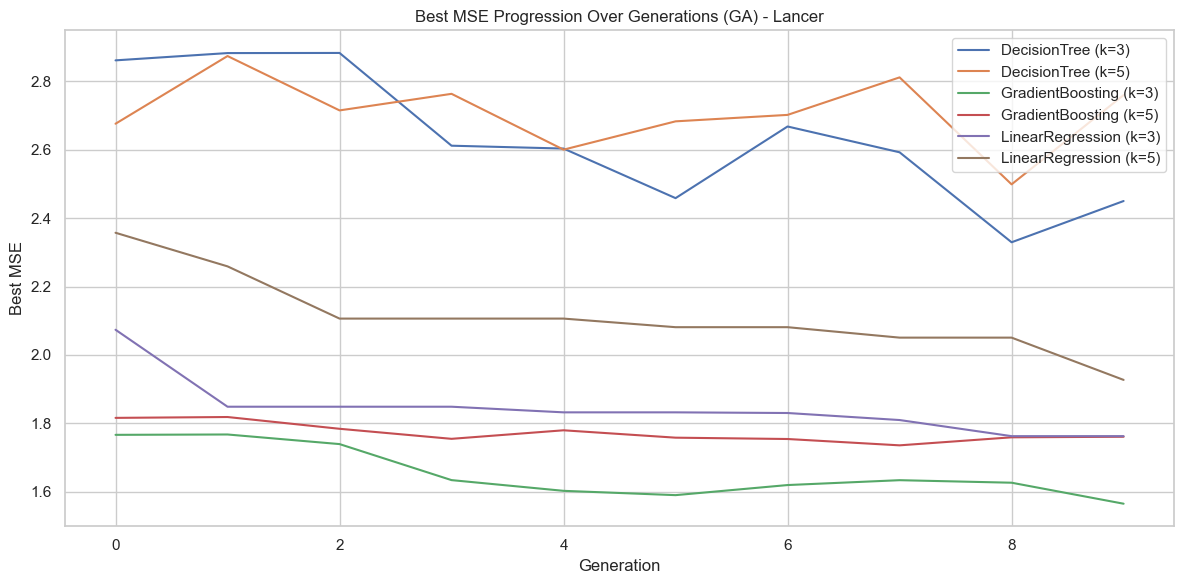

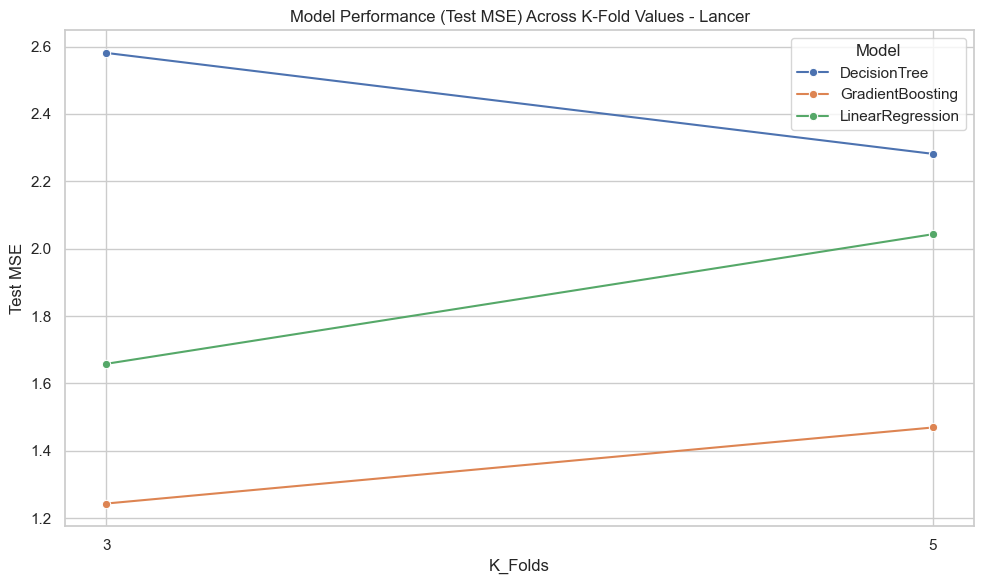

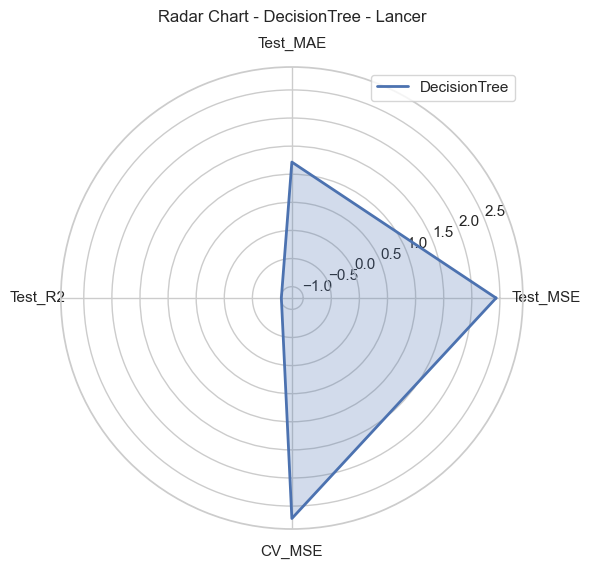

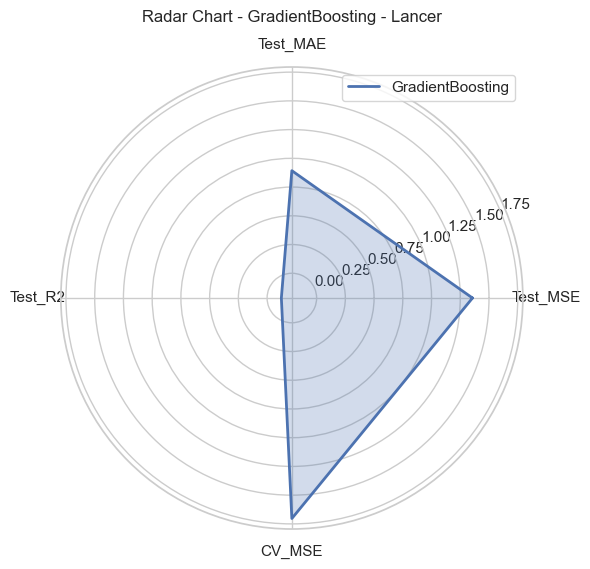

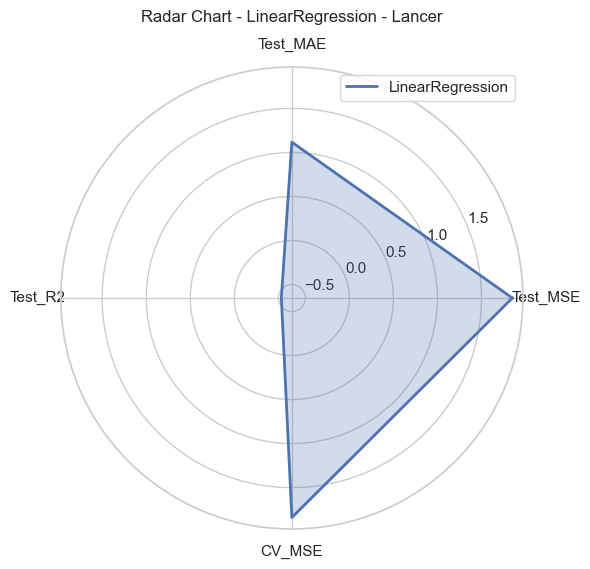

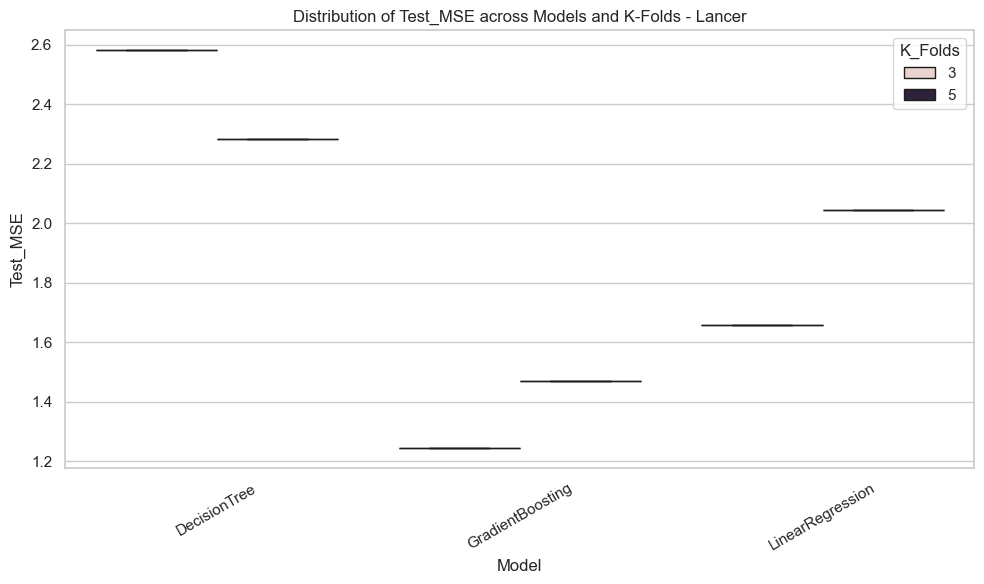

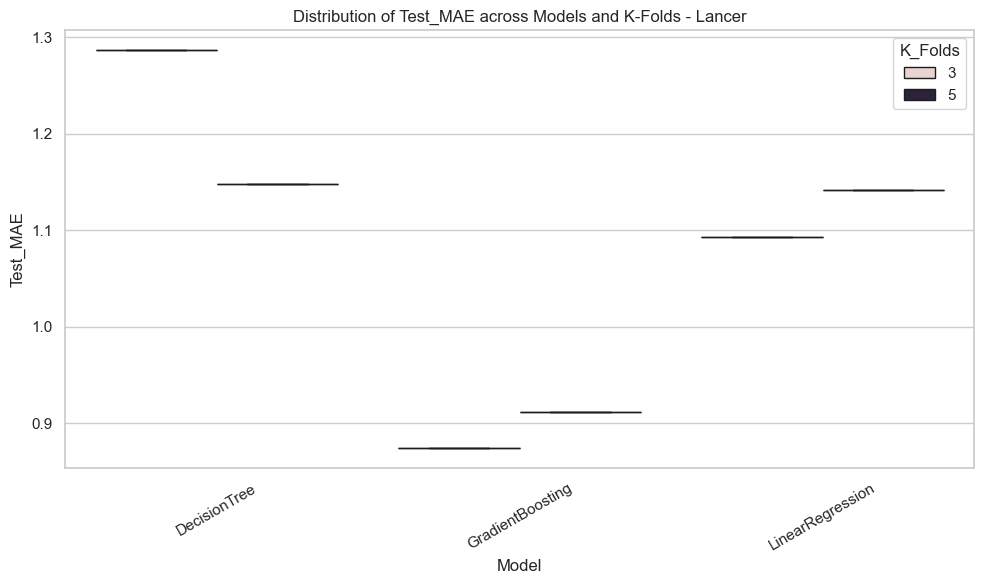

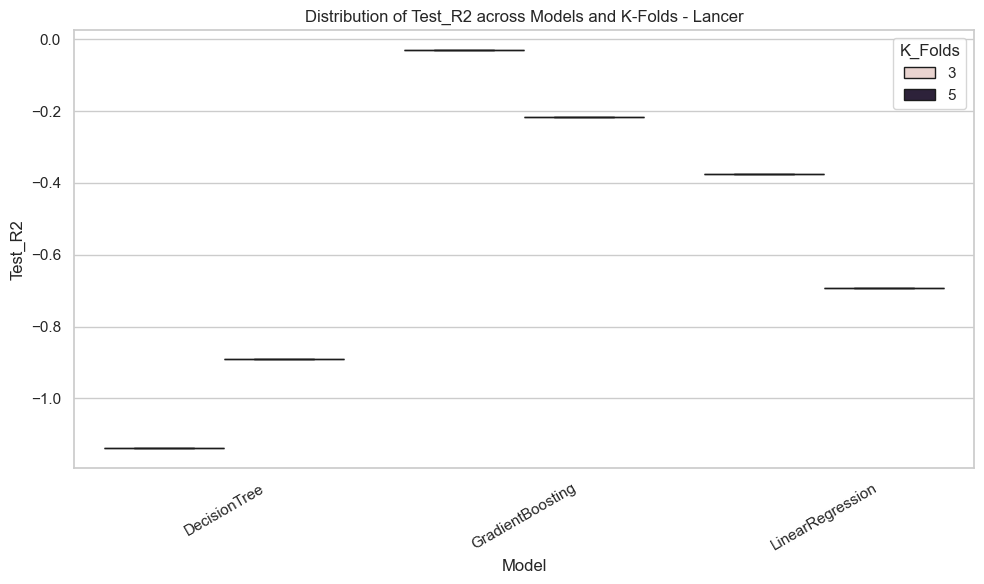

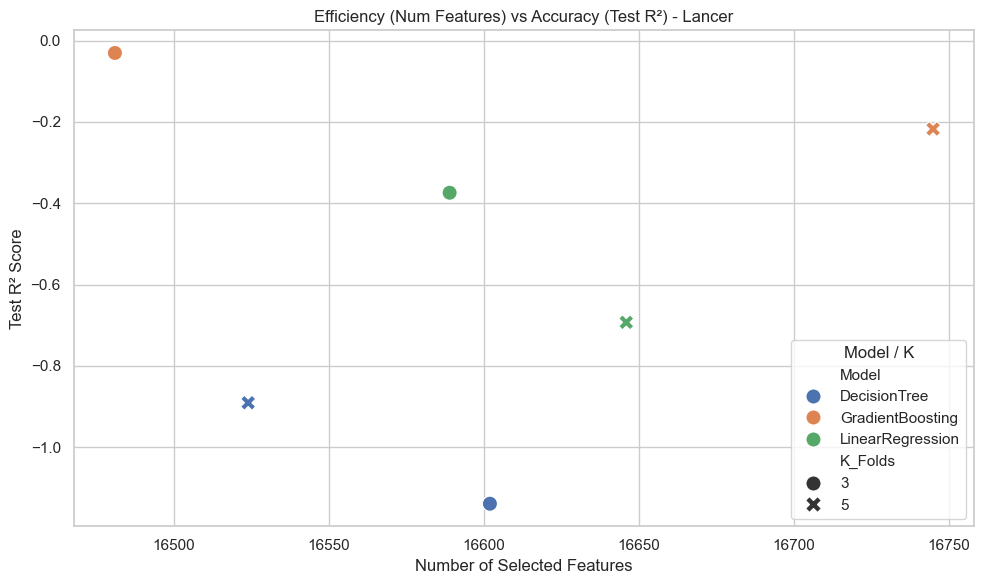

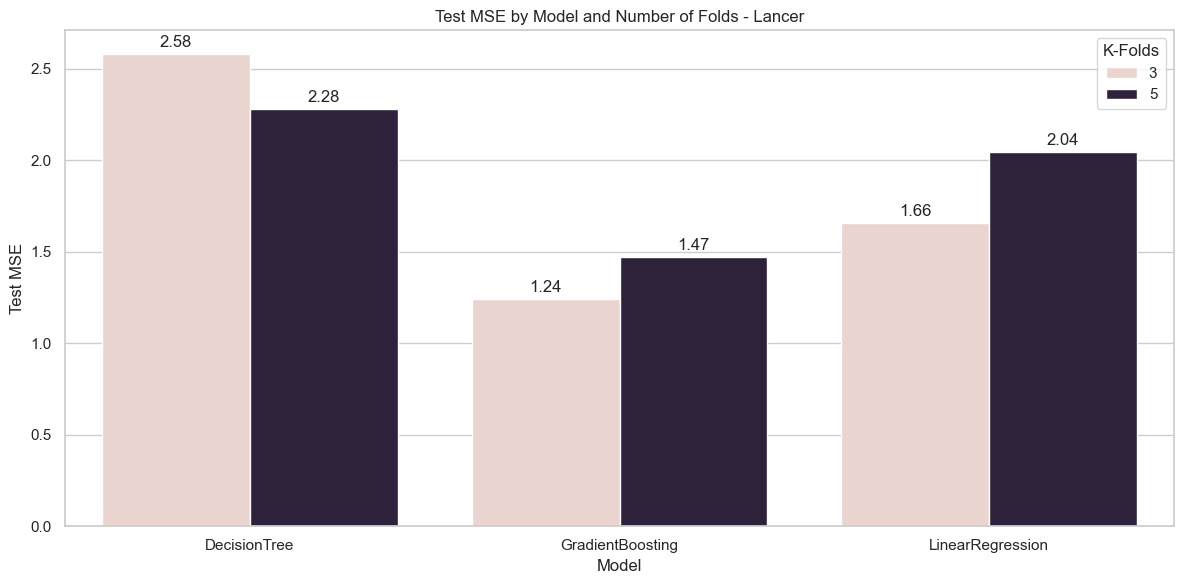

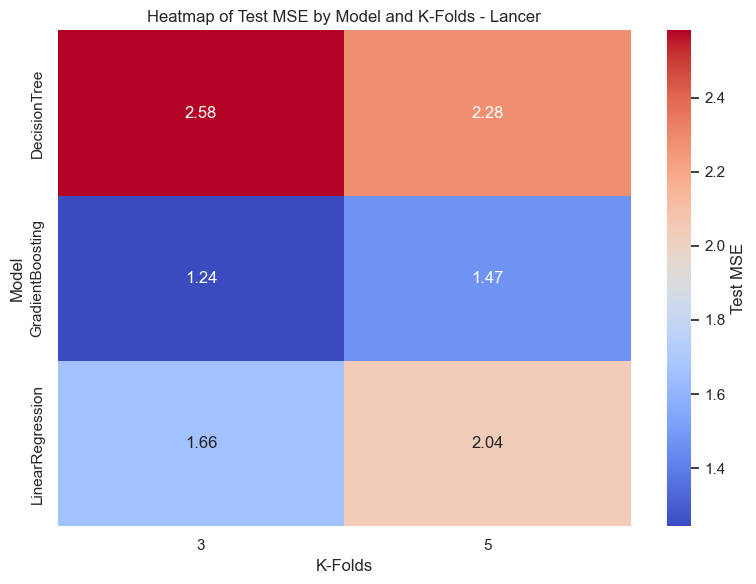

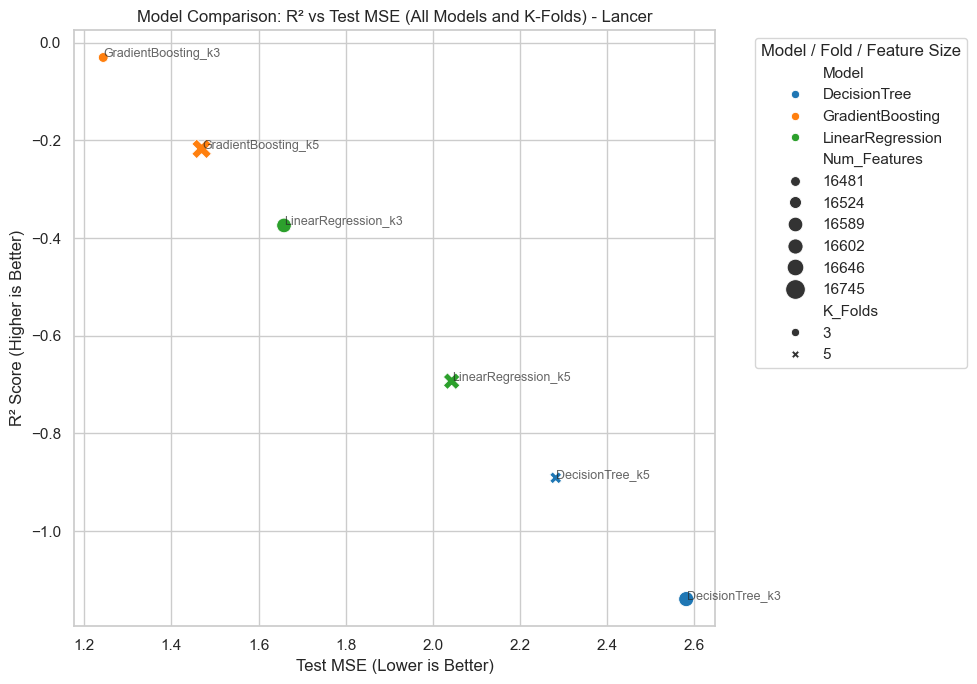

✅ Completed processing for Lancer
\n======================================================================
Processing Dataset: Halberd
File: 3_merged_data5.txt
Target: avg_halberd
Dataset shape: (149, 33050)
Shape of X_train: (119, 33048)
Shape of X_test: (30, 33048)

🧬 Starting Genetic Algorithm training for Halberd
Population size: 20, Generations: 10
Models to test: ['DecisionTree', 'GradientBoosting', 'LinearRegression']
\nRunning GA for DecisionTree with k=3 folds CV - Halberd


GA DecisionTree k=3 - Halberd: 100%|██████████| 10/10 [01:09<00:00,  6.95s/it]


Saved best model for DecisionTree with k=3 at saved_models_genetic_halberd\Halberd_DecisionTree_k3_best_model.joblib
\nRunning GA for DecisionTree with k=5 folds CV - Halberd


GA DecisionTree k=5 - Halberd: 100%|██████████| 10/10 [01:19<00:00,  7.93s/it]


Saved best model for DecisionTree with k=5 at saved_models_genetic_halberd\Halberd_DecisionTree_k5_best_model.joblib
\nRunning GA for GradientBoosting with k=3 folds CV - Halberd


...

Saved best model for GradientBoosting with k=5 at saved_models_genetic_halberd\Halberd_GradientBoosting_k5_best_model.joblib
\nRunning GA for LinearRegression with k=3 folds CV - Halberd


GA LinearRegression k=3 - Halberd: 100%|██████████| 10/10 [01:03<00:00,  6.37s/it]


Saved best model for LinearRegression with k=3 at saved_models_genetic_halberd\Halberd_LinearRegression_k3_best_model.joblib
\nRunning GA for LinearRegression with k=5 folds CV - Halberd


GA LinearRegression k=5 - Halberd: 100%|██████████| 10/10 [01:30<00:00,  9.04s/it]


Saved best model for LinearRegression with k=5 at saved_models_genetic_halberd\Halberd_LinearRegression_k5_best_model.joblib
\nSummary for Halberd:\n    Dataset             Model  K_Folds    CV_MSE  Test_MSE  Test_MAE   Test_R2  \
0  Halberd      DecisionTree        3  3.161076  2.781717  1.423000 -0.847883   
1  Halberd      DecisionTree        5  2.890736  3.545870  1.523667 -1.355507   
2  Halberd  GradientBoosting        3  1.806809  1.946104  0.977816 -0.292789   
3  Halberd  GradientBoosting        5  1.870152  1.477952  0.977740  0.018202   
4  Halberd  LinearRegression        3  1.837127  2.379501  1.246821 -0.580693   
5  Halberd  LinearRegression        5  1.981079  2.332777  1.221628 -0.549654   

   Num_Features                                       MSE_Progress  
0         16404  [3.6112781623931625, 3.460806666666667, 3.1259...  
1         16475  [3.5709290579710142, 3.0194894202898555, 3.161...  
2         16466  [1.907082368284328, 1.9073582264764994, 1.9271...  
3     

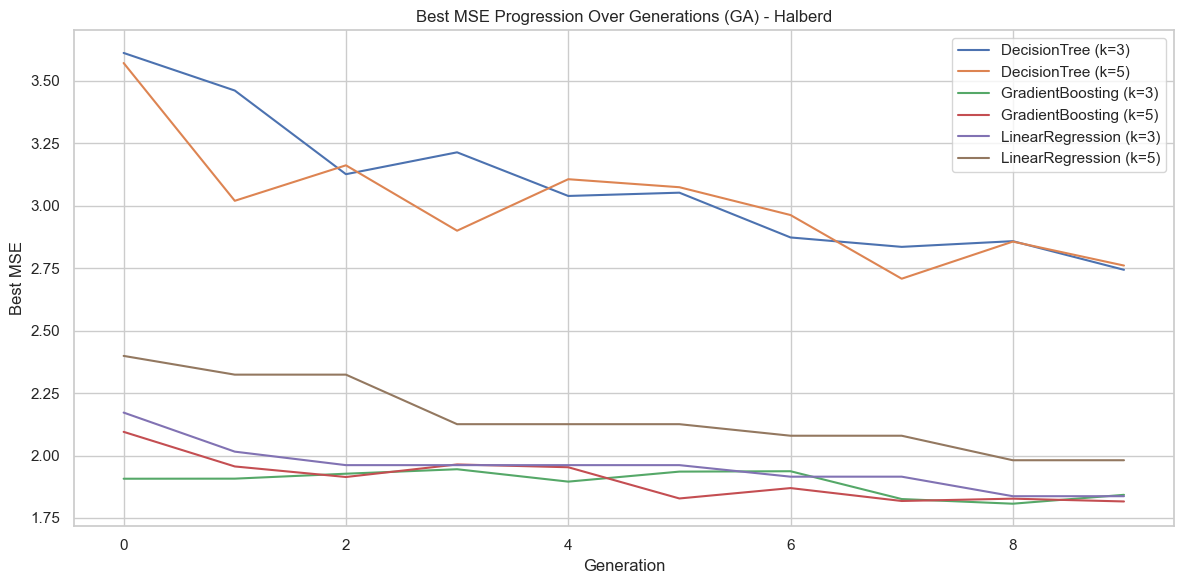

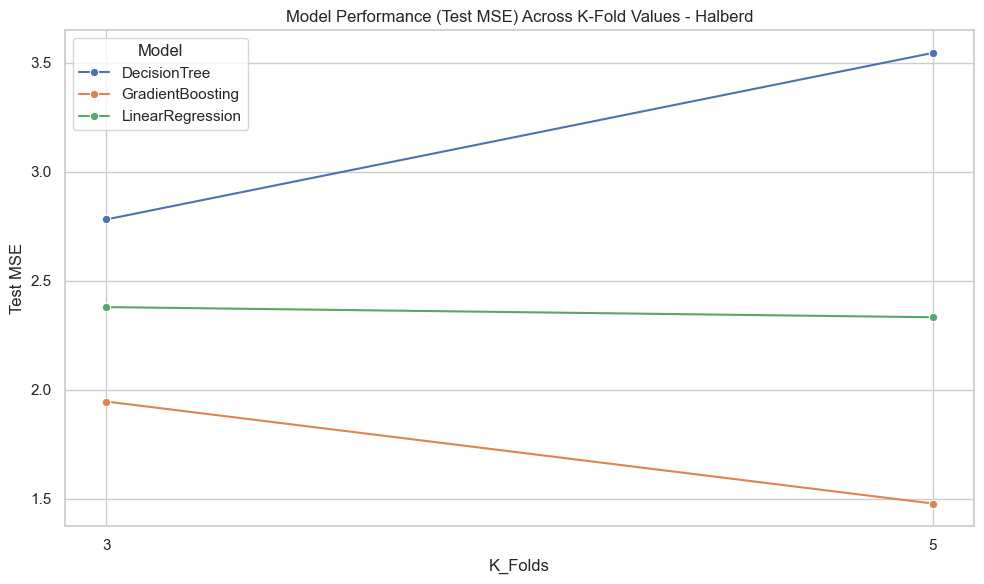

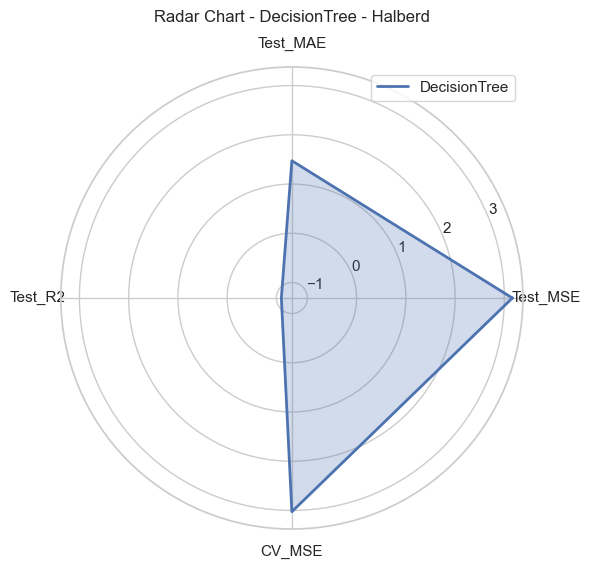

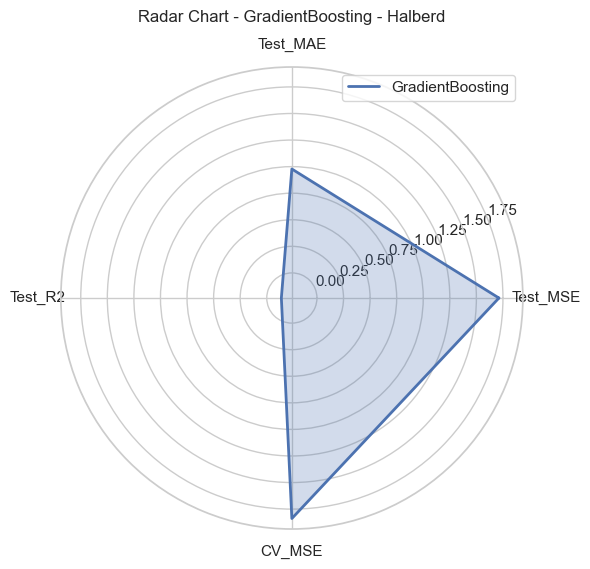

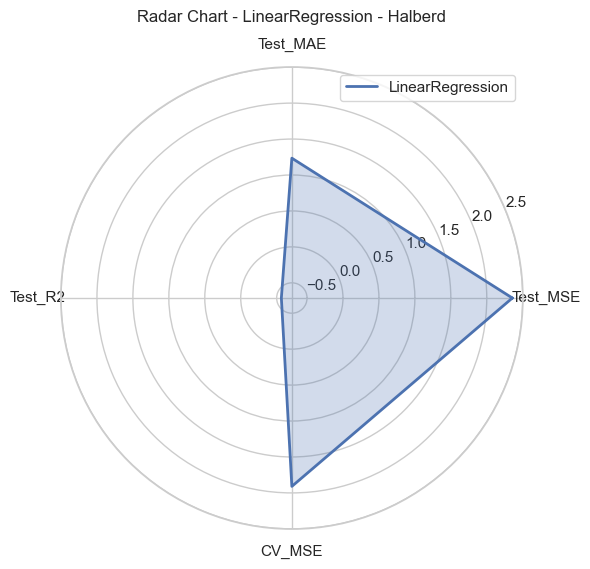

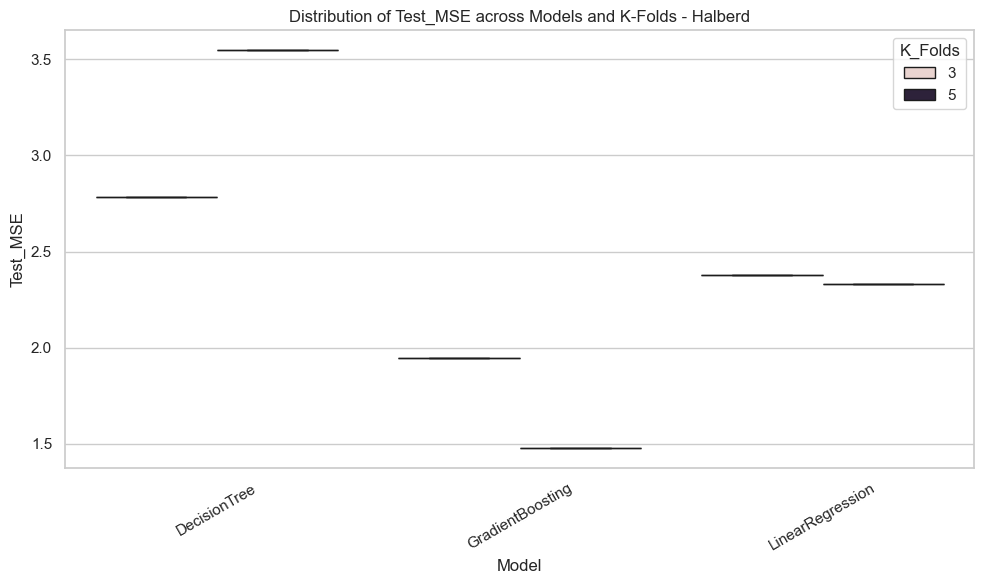

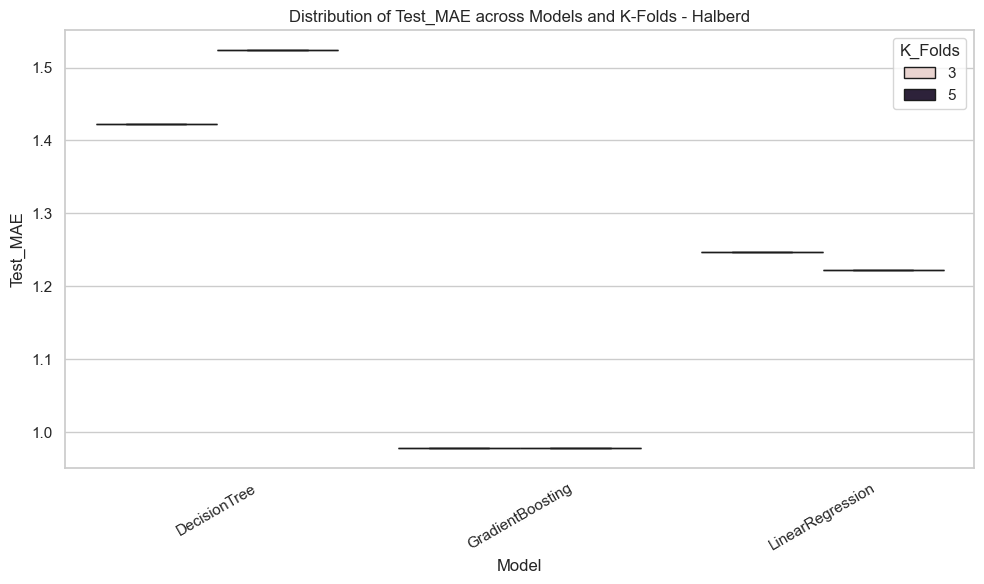

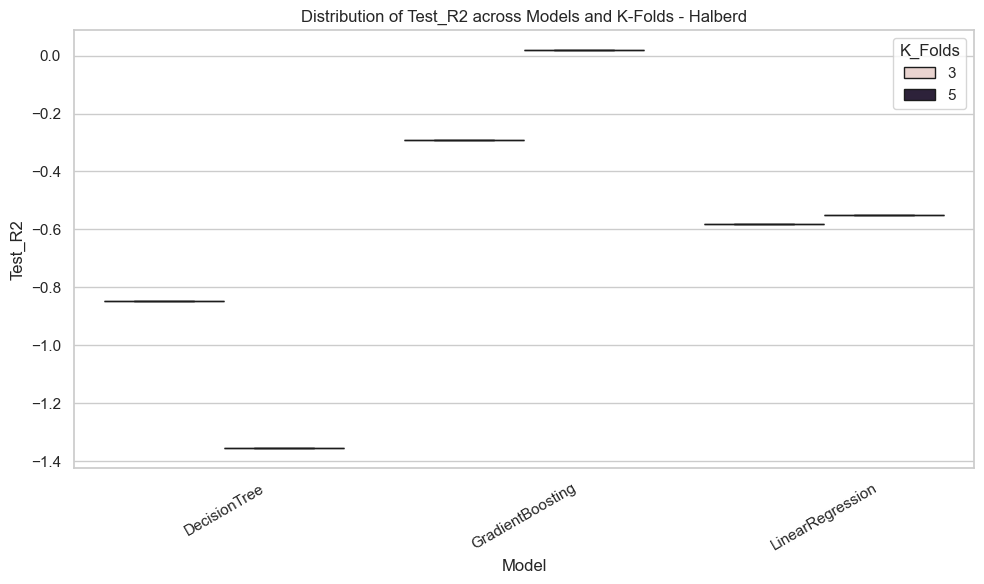

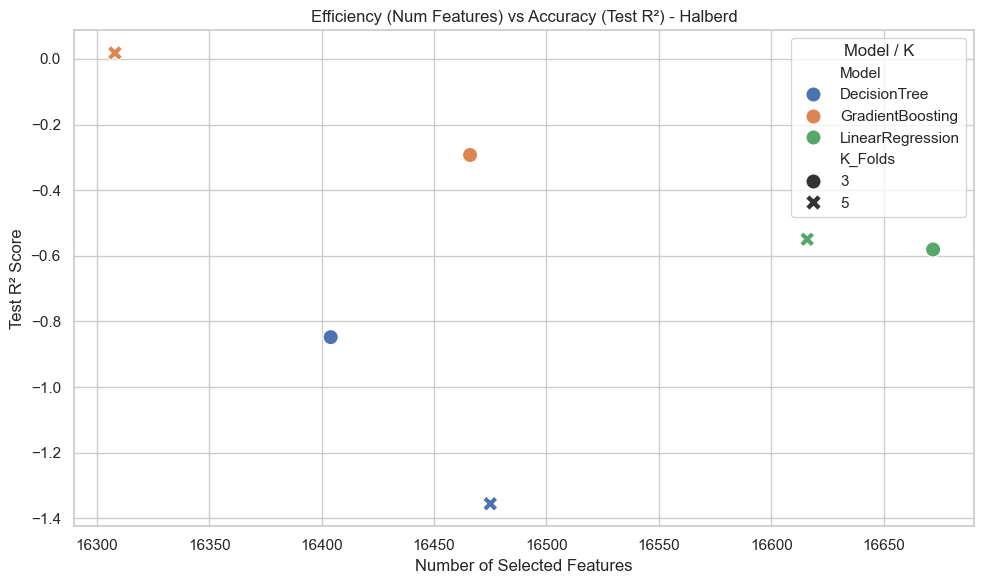

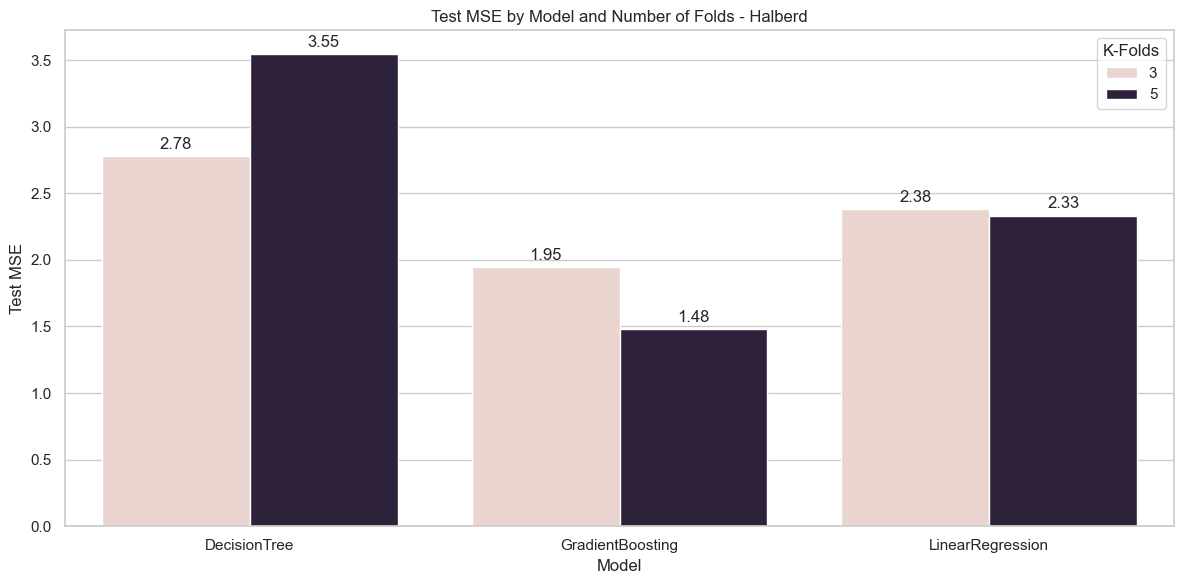

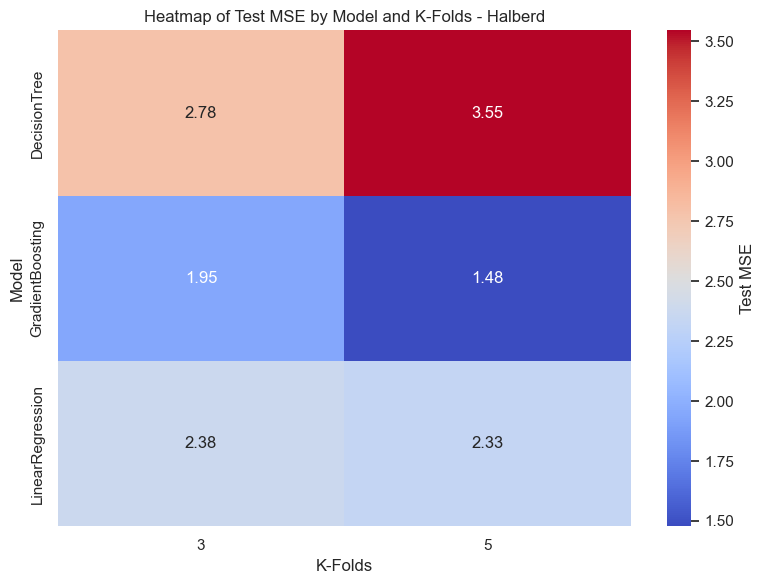

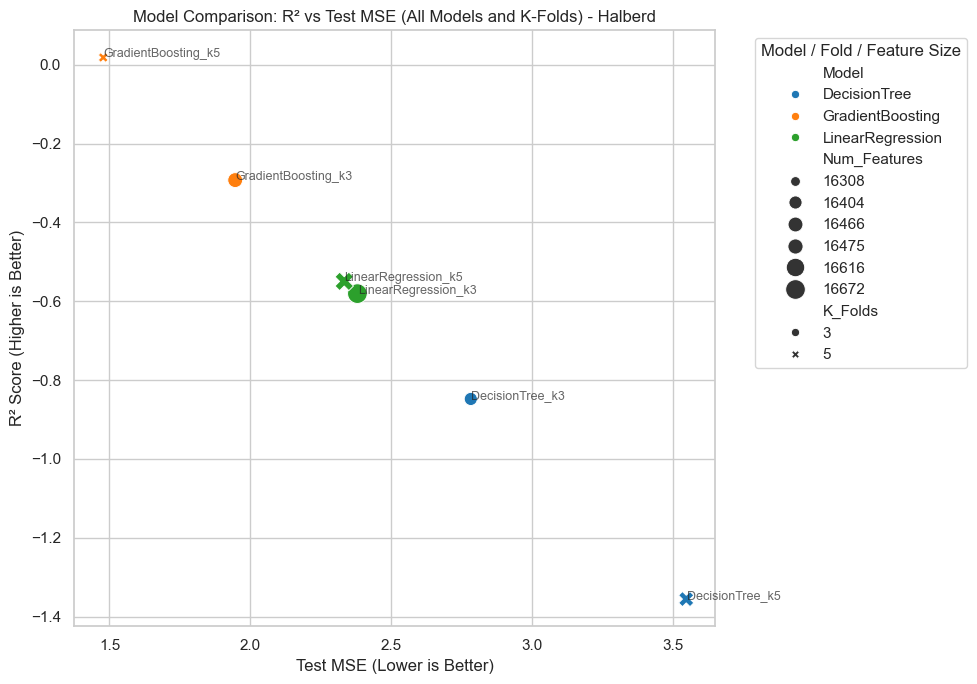

✅ Completed processing for Halberd
\n======================================================================
Creating Cross-Dataset Summary Comparison


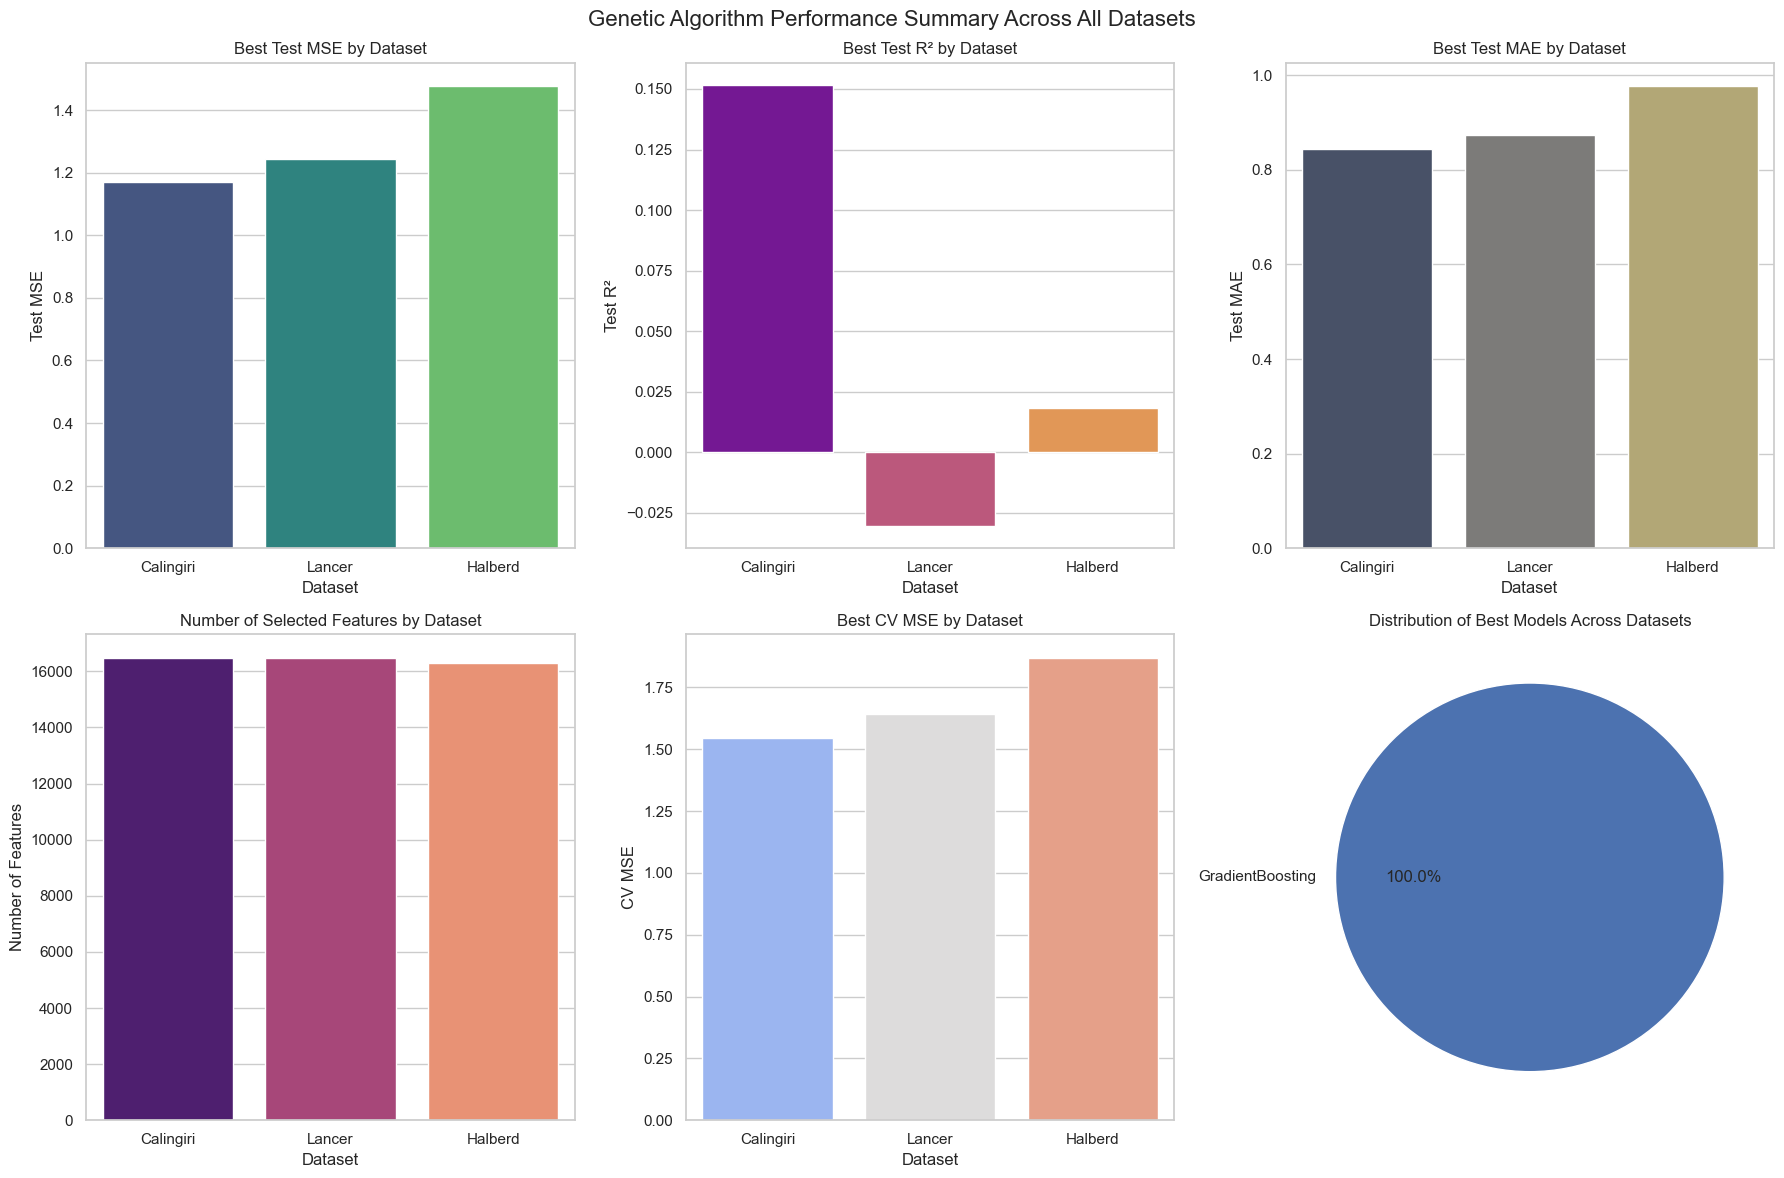

\n📊 Cross-Dataset Final Summary:
  Dataset       Best_Model  K_Folds  Test_MSE  Test_MAE   Test_R2   CV_MSE  Num_Features
Calingiri GradientBoosting        5  1.168626  0.844637  0.151793 1.544252         16487
   Lancer GradientBoosting        3  1.243511  0.873915 -0.030485 1.642525         16481
  Halberd GradientBoosting        5  1.477952  0.977740  0.018202 1.870152         16308
\n======================================================================
Best Model Performance Summary by Dataset
\nCalingiri:
  Best Model: GradientBoosting
  K-Folds: 5
  Selected Features: 16487
  Test MSE: 1.1686
  Test MAE: 0.8446
  Test R²: 0.1518
\nLancer:
  Best Model: GradientBoosting
  K-Folds: 3
  Selected Features: 16481
  Test MSE: 1.2435
  Test MAE: 0.8739
  Test R²: -0.0305
\nHalberd:
  Best Model: GradientBoosting
  K-Folds: 5
  Selected Features: 16308
  Test MSE: 1.4780
  Test MAE: 0.9777
  Test R²: 0.0182
\n======================================================================
🎉 Multi

In [19]:
# Execute if run directly
if __name__ == "__main__":
    main()